### Classification in Business

The goal of this analysis is to build a logistic regression model to predict whether an employee will leave the company (attrition) based on their workload, performance, satisfaction, and other factors. This is a binary classification problem where the target variable is `attrition` (Yes/No).

Based on the results of the logistic regression model, the company can identify key factors that contribute to employees leaving. This insight can help HR and management take proactive measures to improve employee retention. For example, if the model identifies that high workload and low job satisfaction are significant predictors of attrition, the company can implement strategies such as workload redistribution, employee wellness programs, or initiatives to boost job satisfaction. Ultimately, this can lead to reduced employee leaving the company, lower recruitment costs, and a more engaged workforce.

## 1. The dataset and its features

Employee Workload and Attrition Analysis:

This HR dataset contains information about employees' workload, performance, satisfaction, demographics, and whether they left the company (attrition). The dataset includes the following features:

**Source:** [Kaggle - Employee Workload and Attrition Analysis](https://www.kaggle.com/datasets/jayjoshi37/employee-workload-and-attrition-analysis)

**Key Features:**
- **employee_id:** Unique identifier for each employee.
- **department:** Department in which the employee works.
- **role_level:** Job seniority level of the employee (Junior, Mid, Senior).
- **monthly_salary:** Monthly salary of the employee.
- **avg_weekly_hours:** Average number of hours worked by the employee per week.
- **projects_handled:** Number of active projects currently handled by the employee.
- **performance_rating:** Annual performance rating of the employee on a scale of 1 to 5.
- **absences_days:** Number of days the employee was absent during the year.
- **job_satisfaction:** Job satisfaction score of the employee on a scale of 1 to 5.
- **attrition:** Indicates whether the employee left the organization (Yes) or stayed (No).


## 2. The Classification Problem

The goal of this analysis is to build a classification model to predict whether an employee will leave the company (attrition) based on their workload, performance, satisfaction, and other factors. This is a binary classification problem where the target variable is `attrition` (Yes/No).

**Target Variable:**  `attrition` (whether the employee left the company or not)
1. **Positive Class (1):**  `Yes` (The employee left)
2. **Negative Class(0):** `No` (The employee stayed)

By building a logistic regression model to predict employee attrition, the company can identify key factors that contribute to employees leaving. This insight can help HR and management take proactive measures to improve employee retention. For example, if the model identifies that high workload and low job satisfaction are significant predictors of attrition, the company can implement strategies such as workload redistribution, employee wellness programs, or initiatives to boost job satisfaction. Ultimately, this can lead to reduced turnover rates, lower recruitment costs, and a more engaged workforce.


## 3. Import Libraries



In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier

from sklearn.preprocessing import StandardScaler,OrdinalEncoder,PolynomialFeatures, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, cohen_kappa_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# import function to perform feature selection
from sklearn.feature_selection import RFE

## 4. Data Preparation

Read the dataset into a pandas DataFrame and perform any necessary preprocessing steps, such as handling missing values, encoding categorical variables, and splitting the data into features and target variable.

### 4.1 Read the dataset

Read csv and show the first few rows of the dataset to understand its structure and contents.

In [23]:
employee_df = pd.read_csv('data/employee_performance_workload_attrition.csv')

employee_df.head(10)

,employee_id,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition
0,1,HR,Junior,81750,55,1,1,17,1,Yes
1,2,Engineering,Senior,58140,36,2,4,13,1,Yes
2,3,Finance,Mid,37747,61,2,2,20,5,No
3,4,Finance,Senior,81993,36,4,1,17,2,Yes
4,5,Sales,Senior,45439,53,5,5,5,1,No
5,6,Operations,Junior,78810,38,2,5,1,5,No
6,7,Operations,Senior,86045,59,6,4,18,4,Yes
7,8,Sales,Junior,61994,37,5,5,15,3,No
8,9,HR,Senior,39594,38,7,2,10,2,No
9,10,Marketing,Junior,117584,37,6,3,11,5,No


#### Numbers of observations and features

In [3]:
employee_df.shape

(2800, 10)

***Interpretation:*** The dataset contains 2800 observations (rows) and 10 features (columns). This indicates that we have a moderate-sized dataset with a reasonable number of features to work with for our classification task. The number of observations is sufficient to train a logistic regression model, and the number of features allows us to capture various aspects of employee workload, performance, satisfaction, and demographics that may influence attrition.

In [4]:
employee_df.describe()

,employee_id,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,74492.075000,49.842500,4.519286,2.960714,9.995000,2.995357
std,808.434702,25899.209391,8.980976,2.286778,1.404794,6.056656,1.414332
min,1.000000,30006.000000,35.000000,1.000000,1.000000,0.000000,1.000000
25%,700.750000,51665.000000,42.000000,3.000000,2.000000,5.000000,2.000000
50%,1400.500000,74587.500000,50.000000,4.000000,3.000000,10.000000,3.000000
75%,2100.250000,97249.500000,57.000000,7.000000,4.000000,15.000000,4.000000
max,2800.000000,119977.000000,65.000000,8.000000,5.000000,20.000000,5.000000


***Interpretation:*** The summary statistics of the numerical features in the dataset provide insights into their distributions and ranges. For example, the `monthly_salary` feature has a mean of `$74,492` with a standard deviation of `25,899`, indicating variability in employee salaries. The `avg_weekly_hours` feature has a mean of about `49` hours, which indicates employees are working overtime considering a typical work week of `40` hours. The `projects_handled` feature shows that employees are handling an average of `4.5` projects, with some handling up to `8` projects. The `performance_rating` have a mean of `2.96` on a scale from `1 to 5`, suggesting employees have moderate performance rating. The `job_satisfaction` mean is `2.99`, indicating an moderate satisfaction level. The `absences_days` feature has a mean of about `10` days, indicating that employees take some time off during the year. These insights can help us understand the characteristics of the workforce and how they may relate to attrition.

### 4.2 Check Data Types

Check the data type of each variable. If the data type is not as per the data definition, change the data type.

In [5]:
employee_df.dtypes

employee_id            int64
department            object
role_level            object
monthly_salary         int64
avg_weekly_hours       int64
projects_handled       int64
performance_rating     int64
absences_days          int64
job_satisfaction       int64
attrition             object
dtype: object

***Interpretation:*** The dataset contains a mix of data types. The `employee_id` is an integer, while `department`, `role_level`, and `attrition` are categorical variables represented as objects (strings). The remaining features such as `monthly_salary`, `avg_weekly_hours`, `projects_handled`, `performance_rating`, `absences_days`, and `job_satisfaction` are numerical variables.

### 4.3 Handle Missing Values and Remove insignificant variables

Check for missing values in the dataset and decide on an appropriate strategy to handle them (e.g., imputation, removal). Also remove any insignificant variables that may not contribute to the classification model such as `employee_id` which is just a unique identifier and does not provide any predictive power for the target variable `attrition`.

In [6]:
employee_df.isna().sum()

employee_id           0
department            0
role_level            0
monthly_salary        0
avg_weekly_hours      0
projects_handled      0
performance_rating    0
absences_days         0
job_satisfaction      0
attrition             0
dtype: int64

***Interpretation:*** The dataset does not contain any missing values, which means we can proceed with our analysis without needing to perform imputation or removal of rows/columns due to missing data.

#### Remove insignificant column `employee_id` as it is just a unique identifier and does not provide any predictive power for the target variable `attrition`.

In [7]:
employee_df = employee_df.drop(columns=['employee_id'])
employee_df

,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition
0,HR,Junior,81750,55,1,1,17,1,Yes
1,Engineering,Senior,58140,36,2,4,13,1,Yes
2,Finance,Mid,37747,61,2,2,20,5,No
3,Finance,Senior,81993,36,4,1,17,2,Yes
4,Sales,Senior,45439,53,5,5,5,1,No
...,...,...,...,...,...,...,...,...,...
2795,HR,Senior,94356,44,7,4,0,5,No
2796,Finance,Senior,88087,54,7,2,14,4,No
2797,Marketing,Senior,41148,60,8,3,10,1,Yes
2798,Finance,Senior,47878,56,5,5,2,5,No


***Interpretation:*** The `employee_id` column has been removed from the dataset as it does not contribute to the predictive power of our classification model.

#### 4.4 Check for unique values in categorical variables

Check the unique values in the categorical variables `department`, `role_level`, and `attrition` to understand the categories present in each variable and to ensure that they are correctly represented for encoding later on.

In [8]:
obj_cols = employee_df.select_dtypes(object)

for col in obj_cols:
    print(f"Unique values in '{col}': {employee_df[col].unique()}")

Unique values in 'department': ['HR' 'Engineering' 'Finance' 'Sales' 'Operations' 'Marketing']
Unique values in 'role_level': ['Junior' 'Senior' 'Mid']
Unique values in 'attrition': ['Yes' 'No']


***Interpretation:*** The `department` column has six unique values: `'HR' 'Engineering' 'Finance' 'Sales' 'Operations' 'Marketing'`. The `role_level` column has three unique values: `'Junior' 'Mid' 'Senior'`. The `attrition` column has two unique values: `'Yes' and 'No'`. This indicates that the categorical variables are correctly represented and can be encoded for use in our classification model. The `department` variable will need to be one-hot encoded, while the `attrition` variable will be label encoded to convert it into a binary format suitable for logistic regression.

The `role_level` column is an ordinal variable with a natural order (Junior < Mid < Senior), so it can be encoded using ordinal encoding, which assigns integer values based on the order of the categories.

#### 4.5 Check for unique values in ordinal variables

Ordinal variables such as `performance_rating`, `projects_handled`, and `job_satisfaction` should have a clear order. Check the unique values in these variables to confirm that they are correctly represented for modeling.

In [9]:
cat_cols = employee_df[['performance_rating', 'projects_handled', 'job_satisfaction']]

for col in cat_cols:
    print(f"Unique values in '{col}': {employee_df[col].unique()}")

Unique values in 'performance_rating': [1 4 2 5 3]
Unique values in 'projects_handled': [1 2 4 5 6 7 8 3]
Unique values in 'job_satisfaction': [1 5 2 4 3]


***Interpretation:*** The `performance_rating` variable has unique values of `1, 2, 3, 4, 5`, which indicates that it is correctly represented as an ordinal variable with a clear order from lowest to highest performance. The `projects_handled` variable has unique values ranging from `0 to 8`, which indicates that it is also correctly represented as an ordinal variable with a natural order based on the number of projects handled. The `job_satisfaction` variable has unique values of `1, 2, 3, 4, 5`, which indicates that it is correctly represented as an ordinal variable with a clear order from lowest to highest satisfaction. These variables can be used directly in the logistic regression model without further encoding since they are already in a numerical format that reflects their ordinal nature.

### 5. Data Visualization

Here I will create visualizations of distributions of key features and their relationships with the target variable `attrition` to gain insights into the data and identify potential patterns that may help in building the classification model.

#### 5.1 Distruibution of the target variable `attrition`

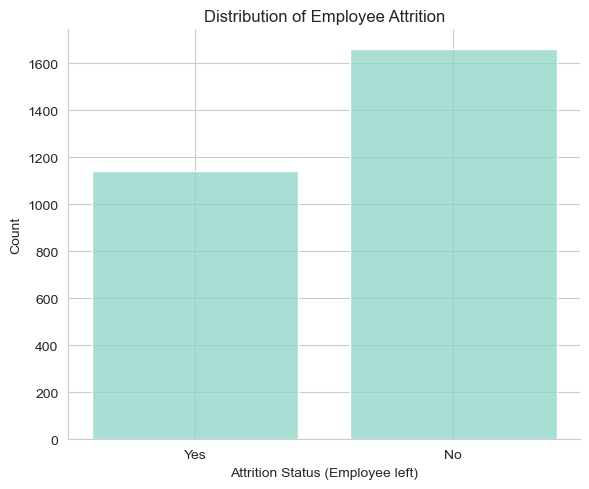

In [10]:
sns.set_style('whitegrid')  # cleaner background

sns.displot(data=employee_df, x='attrition', shrink=0.8, height=5, aspect=1.2)
plt.title('Distribution of Employee Attrition')
plt.ylabel('Count')
plt.xlabel('Attrition Status (Employee left)')
plt.tight_layout()
plt.show()

In [11]:
percentage_attrition = employee_df['attrition'].value_counts(normalize=True) * 100
print("Percentage of Employees who left (Attrition = Yes): {:.2f}%".format(percentage_attrition['Yes']))
print("Percentage of Employees who stayed (Attrition = No): {:.2f}%".format(percentage_attrition['No']))

Percentage of Employees who left (Attrition = Yes): 40.71%
Percentage of Employees who stayed (Attrition = No): 59.29%


***Interpretation:*** The distribution of the target variable `attrition` shows that `40.71%` of employees left the company (attrition = Yes), while `59.29%` of employees stayed (attrition = No). This indicates that there is a significant portion of employees who have left the company, which highlights the importance of understanding the factors contributing to attrition and building a classification model to predict it.

#### 5.2 Distribution of numerical features


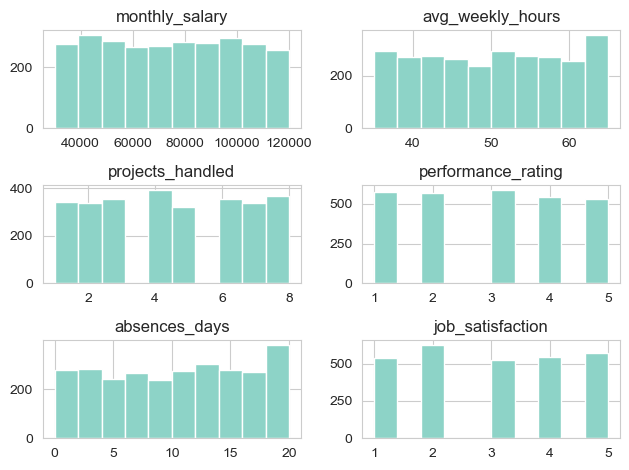

In [12]:
employee_df.drop('attrition', axis=1).hist()
plt.tight_layout()
plt.show()

***Interpretation:***

* The `monthly_salary` feature are spread fairly evenly across the salary range (approximately `$30,000 to $120,000`). There are no significant "peaks" at specific salary levels, suggesting the dataset includes a diverse range of income levels without a heavy bias toward entry-level or executive pay.
* The `avg_weekly_hours` also follows a uniform distribution, with a slight uptick in the final bin (near 65 hours). The slight increase at the high end might indicate a specific group of employees who consistently work maximum overtime.
* The `projects_handled` feature shows a fairly even distribution across the range of 0 to 8 projects, with no significant peaks at specific project counts. This suggests that employees are distributed across various levels of project involvement without a heavy concentration at any particular number of projects.
* The `performance_rating` feature has a relatively uniform distribution across the ratings of 1 to 5, with a slight increase at the rating of 3. This indicates that most employees receive moderate performance ratings, with fewer employees receiving very low (1) or very high (5) ratings.
* The `absences_days` feature shows an uniform distribution with a slight increase at the higher end (near 30 days). This suggests that while most employees take a moderate number of absence days, there is a small group of employees who take significantly more time off.
* The `job_satisfaction` feature is also uniformly distributed across the satisfaction scores of 1 to 5, with a slight increase at the score of 3. This indicates that most employees have moderate job satisfaction, with fewer employees reporting very low (1) or very high (5) satisfaction levels.

#### 5.3 Monthly Salary vs. Attrition

Compare the distribution of `monthly_salary` between employees who left the company (attrition = Yes) and those who stayed (attrition = No) to see if there is a noticeable difference in salary levels between the two groups.




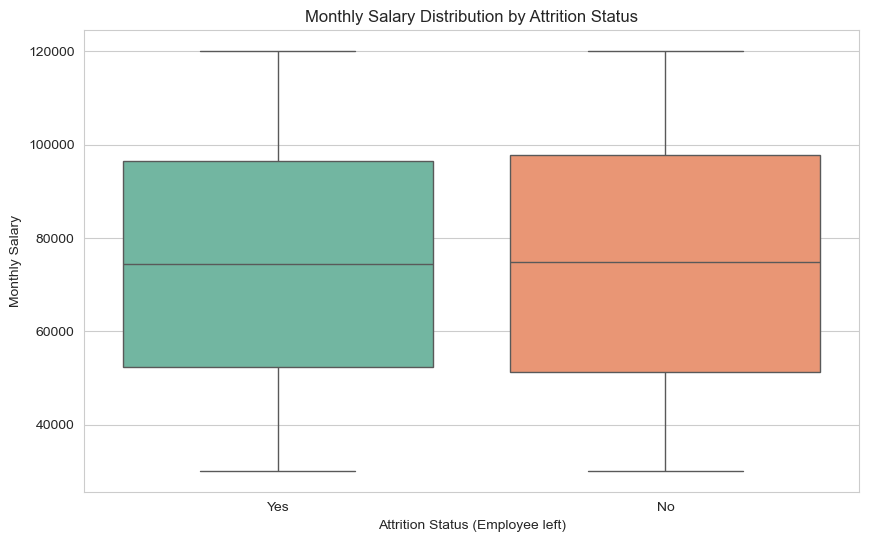

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=employee_df, x='attrition', y='monthly_salary', palette='Set2', hue='attrition',)

plt.title('Monthly Salary Distribution by Attrition Status')
plt.ylabel('Monthly Salary')
plt.xlabel('Attrition Status (Employee left)')
plt.show()

***Interpretation:*** The boxplot comparing `monthly_salary` and `attrition` shows that the median salary is nearly identical for both groups, sitting around $75,000. This suggests that, on average, salary level is not a primary differentiator between employees who stay and those who leave in this specific dataset.

Also, there are no Outliers. There are no individual points (dots) plotted outside the whiskers, meaning the salary distribution is relatively uniform without extreme high or low exceptions in either category.

Based on this visualization alone, monthly salary does not appear to be a strong predictor of employee attrition. Because the distributions are so similar, a Logistic Regression model might find that other factors such as `avg_weekly_hours` (workload) or `job_satisfaction` which may carry more weight in determining why an employee chooses to leave.

#### 5.4 Attrition by Department and Role Level

Are certain departments or role levels more prone to attrition?

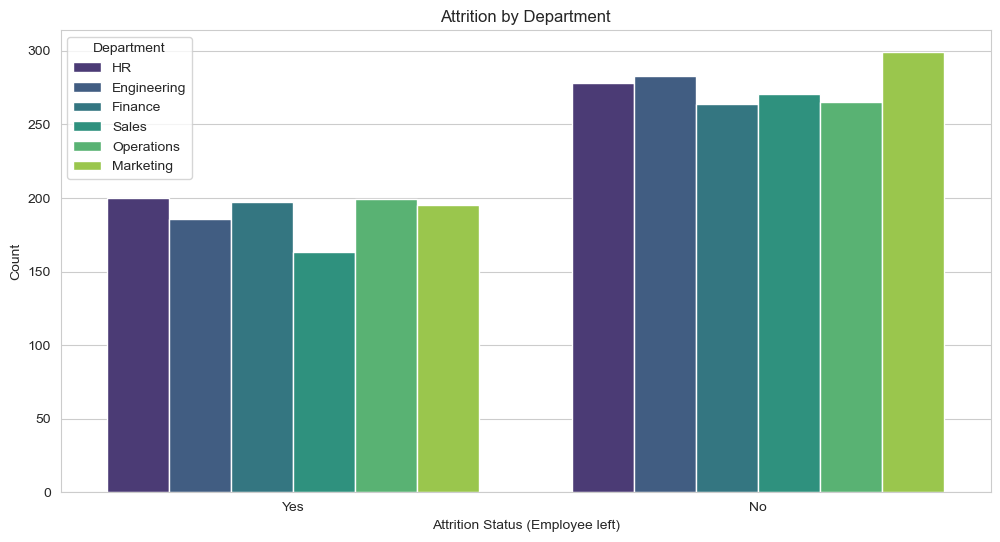

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(data=employee_df, x='attrition', hue='department', palette='viridis')
plt.title('Attrition by Department')
plt.xlabel('Attrition Status (Employee left)')
plt.ylabel('Count')
plt.legend(title='Department')
plt.show()

***Interpretation:*** The countplot shows that attrition is not confined to a single department, every department show a almost similar proportion of employees leaving (attrition = Yes) and staying (attrition = No). However, `HR` and `Operation` departments show the highest counts of employees leaving (arount 200 each), followed by `Finance` and `Marketing`. The `Sales` department has the lowest count of employees leaving. This suggests that while attrition is present across all departments, certain departments like `HR` and `Operations` may have slightly higher attrition rates compared to others. This could be due to various factors such as job stress, workload, or lack of growth opportunities in those departments, which may warrant further investigation.

#### 5.5 Hours vs. Salary by Attrition

Does the relationship between `avg_weekly_hours` and `monthly_salary` differ for employees who left the company (attrition = Yes) compared to those who stayed (attrition = No)?

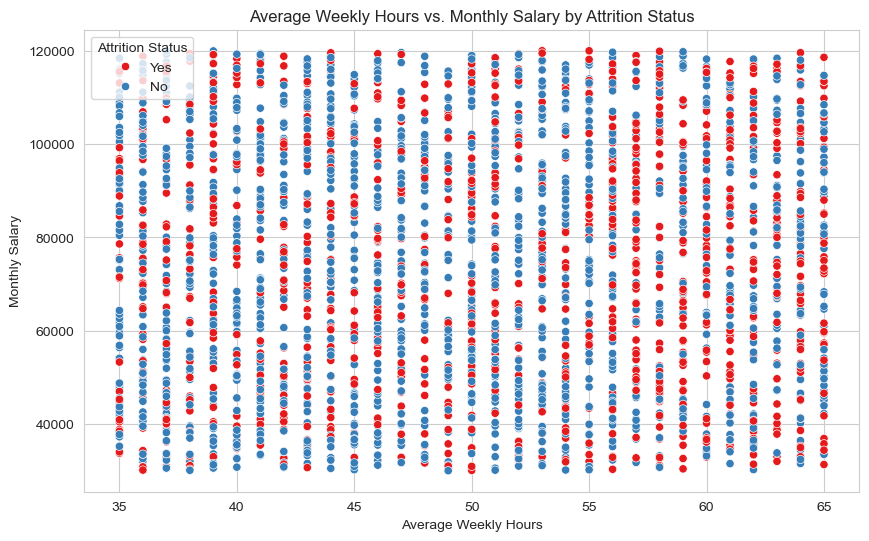

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=employee_df, x='avg_weekly_hours', y='monthly_salary', hue='attrition', palette='Set1')
plt.title('Average Weekly Hours vs. Monthly Salary by Attrition Status')
plt.xlabel('Average Weekly Hours')
plt.ylabel('Monthly Salary')
plt.legend(title='Attrition Status')
plt.show()

***Interpretation:*** The scatterplot comparing `avg_weekly_hours` and `monthly_salary` by `attrition` status shows that there is no clear relationship between these two variables for either group. Both employees who left (attrition = Yes) and those who stayed (attrition = No) are scattered across the range of average weekly hours and monthly salaries without a distinct pattern.

#### 5.6 Heatmap of Correlation Matrix

Validate how numerical features are related to each other and to the target variable `attrition` using a heatmap of the correlation matrix.

Since `attrition` is a categorical variable, I will first need to encode it into a binary format (Yes = 1, No = 0) before calculating the correlation matrix.

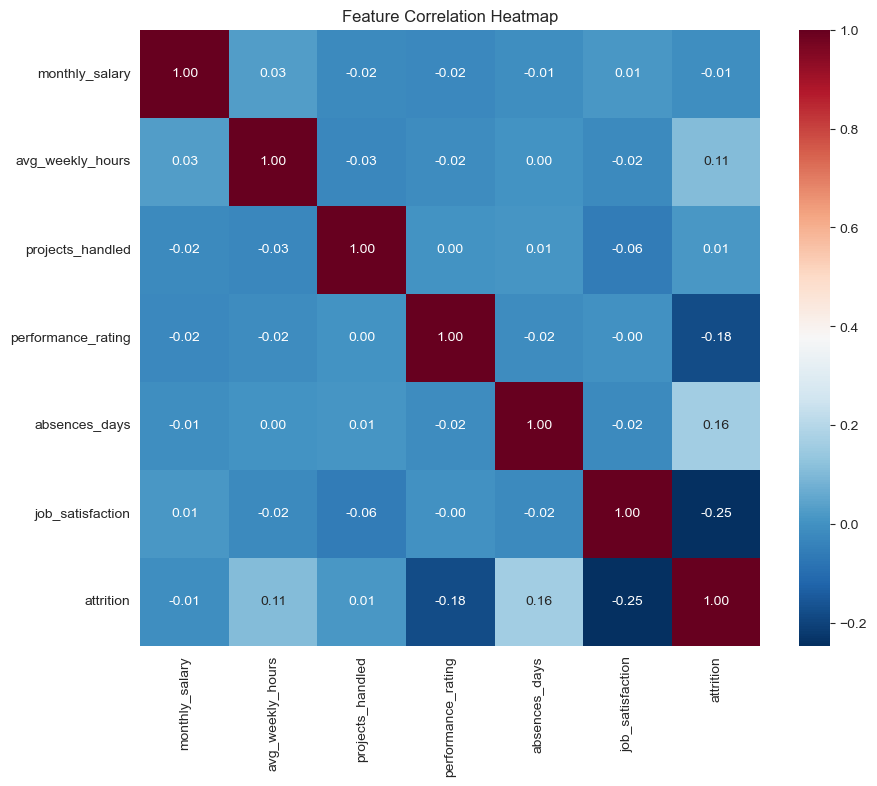

In [16]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
# Mapping attrition to numeric for correlation analysis
corr_df = employee_df.copy()
corr_df['attrition'] = corr_df['attrition'].map({'Yes': 1, 'No': 0})
sns.heatmap(corr_df.select_dtypes('int64').corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

***Interpretation:*** The heatmap of the correlation matrix shows that there are no strong correlations between the numerical features and the target variable `attrition`. The highest correlation with `attrition` is `job_satisfaction` with a value of `-0.25`, indicating a weak negative relationship, and since the target variable is encoded as 1 for "Yes" (employee left) and 0 for "No" (employee stayed), this negative correlation suggests that higher `job_satisfaction` is associated with the employee staying at the company. Another negative correlation with `attrition` is `performance_rating` with a value of `-0.18`, suggesting that if the employee is performing at lower rating are more likely to stay with the company.

The highest positive correlation with `attrition` is with `absences_days` with a value of `0.16`, a weak positive relationship, meaning the higher the absences days, the more likely an employee is to leave. The second highest positive correlation with `attrition` is `avg_weekly_hours` with a value of `0.11`, a weak positive relationship, meaning that employees who work more hours per week are slightly more likely to leave.




### 6. Split the dataset into train/test

The dataset will be split using an 80/20 split, where 80% of the data will be used for training the logistic regression model and 20% will be reserved for testing the model's performance on unseen data. This split allows us to evaluate how well the model generalizes to new data and helps prevent overfitting.

#### 6.1 Perform binary encoding of the target variable `attrition`

The target variable `attrition` is currently represented as categorical values ('Yes' and 'No'). I will encode it into a binary format where 'Yes' is mapped to 1 (indicating the employee left) and 'No' is mapped to 0 (indicating the employee stayed). This encoding is necessary for the logistic regression model to interpret the target variable correctly.

In [17]:
employee_df['attrition_encoded'] = employee_df['attrition'].map({'Yes': 1, 'No': 0})
employee_df.drop(columns=['attrition'], inplace=True)
employee_df

,department,role_level,monthly_salary,avg_weekly_hours,projects_handled,performance_rating,absences_days,job_satisfaction,attrition_encoded
0,HR,Junior,81750,55,1,1,17,1,1
1,Engineering,Senior,58140,36,2,4,13,1,1
2,Finance,Mid,37747,61,2,2,20,5,0
3,Finance,Senior,81993,36,4,1,17,2,1
4,Sales,Senior,45439,53,5,5,5,1,0
...,...,...,...,...,...,...,...,...,...
2795,HR,Senior,94356,44,7,4,0,5,0
2796,Finance,Senior,88087,54,7,2,14,4,0
2797,Marketing,Senior,41148,60,8,3,10,1,1
2798,Finance,Senior,47878,56,5,5,2,5,0


***Interpretation:*** The `attrition` column has been successfully encoded into a new column called `attrition_encoded`, where 'Yes' is represented as 1 and 'No' is represented as 0. The original `attrition` column was dropped because is no longer need it for analysis, as the encoded version provides the necessary information in a format suitable for modeling.

#### 6.2 Separate features and target variable

The features (independent variables) will be stored in a variable `X`, and the target variable `attrition` will be stored in a variable `y`. This separation is necessary for training the logistic regression model, as it requires the features to learn patterns and the target variable to make predictions.

The target variable `attrition` will be encoded into a binary format where 'Yes' is mapped to 1 (indicating the employee left) and 'No' is mapped to 0 (indicating the employee stayed). This encoding is necessary for the logistic regression model to interpret the target variable correctly.

In [18]:
X = employee_df.drop(columns=['attrition_encoded'], axis=1)
y = employee_df['attrition_encoded']
print(X.shape)
print(y.shape)

(2800, 8)
(2800,)


#### 6.3 Perform train/test split

Split the dataset into training and testing sets using an 80/20 split. 

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2240, 8)
(560, 8)
(2240,)
(560,)


***Interpretation:*** The dataset has been successfully split into training and testing sets. The training set contains 2240 observations (80% of the data) and the testing set contains 560 observations (20% of the data). This split allows us to train the logistic regression model on the training data and evaluate its performance on the unseen testing data, which helps to assess how well the model generalizes to new data.

#### 6.4 Function to check model performance

In [20]:
# create an empty dataframe to store the scores for various algorithms
score_card = pd.DataFrame(columns=['Probability Cutoff', 'AUC Score', 'Precision Score',
                                   'Recall Score','Accuracy Score', 'Kappa Score', 'f1-score'])

# append the result table for all performance scores
# performance measures considered for model comparision are 'AUC Score', 'Precision Score', 'Recall Score','Accuracy Score',
# 'Kappa Score', and 'f1-score'
# compile the required information in a user defined function
def update_score_card(model, cutoff):

    # let 'y_pred_prob' be the predicted values of y
    y_pred_prob = model.predict(X_test)

    # convert probabilities to 0 and 1 using 'if_else'
    y_pred = [ 0 if x < cutoff else 1 for x in y_pred_prob]

    # assign 'score_card' as global variable
    global score_card

    # append the results to the dataframe 'score_card'
    # 'ignore_index = True' do not consider the index labels
    score_card = score_card.append({'Probability Cutoff': cutoff,
                                    'AUC Score' : roc_auc_score(y_test, y_pred),
                                    'Precision Score': precision_score(y_test, y_pred),
                                    'Recall Score': recall_score(y_test, y_pred),
                                    'Accuracy Score': accuracy_score(y_test, y_pred),
                                    'Kappa Score':cohen_kappa_score(y_test, y_pred),
                                    'f1-score': f1_score(y_test, y_pred)},
                                    ignore_index = True)

### 7. Feature Engineering:

#### Data Transformation and Encoding

In this step, I will create a transformer to perform the necessary data transformations and encoding for the logistic regression model. This will include one-hot encoding for nominal categorical variables, ordinal encoding for ordinal categorical variables, and scaling for numerical variables.

The transformer will be the following:
- One-hot encoding for the `department` variable, which is a nominal categorical variable with no inherent order.
- Ordinal encoding for the `role_level` variable, which is an ordinal categorical variable with a natural order (Junior < Mid < Senior).
- Scaling for the numerical variables `monthly_salary`, `avg_weekly_hours`, and `absences_days` to ensure that they are on a similar scale

For columns that do not require transformation, I will set `remainder='passthrough'` in the `ColumnTransformer` to ensure that they are included in the output without modification. This columns are `projects_handled`, `performance_rating`, and `job_satisfaction` which are already in a numerical format that reflects their ordinal nature and can be used directly in the logistic regression model without further encoding.

##### 7.1 Column Transformer for Data Transformation

In [ ]:
nominal_col = ['department']
ordinal_col = ['role_level']
numerical_cols = ['monthly_salary', 'avg_weekly_hours', 'absences_days']


transformer = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(), nominal_col),
        ('ordinal', OrdinalEncoder(), ordinal_col),
        ('scaler', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)